In [4]:
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

# R2 평가지표로 모델 성능 확인

In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


# 데이터를 읽고 전 처리합니다
df = pd.read_csv("d/Advertising.csv")
df = df.drop(columns=['Unnamed: 0'])

X = df.drop(columns=['Sales'])
y = df['Sales']

# 훈련데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=50) # random_state값을 다르게 했을 때도 높은 점수라면 잘 학습한 모델임


# 다중 선형 회귀 모델을 초기화 하고 학습합니다
lg_clf2 = LinearRegression()
lg_clf2.fit(X_train, y_train)

# train_X 의 예측값을 계산합니다
pred_train = lg_clf2.predict(X_train)

"""
1. train_X 의 R2 값을 계산합니다
"""
R2_train = r2_score(y_train, pred_train)
print('R2_train : %f' % R2_train)  # R2_train : 0.895701

# test_X 의 예측값을 계산합니다
pred_test = lg_clf2.predict(X_test)
R2_test = r2_score(y_test, pred_test)

"""
2. test_X 의 R2 값을 계산합니다
"""

print('R2_test : %f' % R2_test)  # R2_test : 0.899438

R2_train : 0.901371
R2_test : 0.847551


# 보스턴 집값 분석 및 머신러닝 집값 예측

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

In [128]:
data_url = "https://lib.stat.cmu.edu/datasets/boston"
# 아래의 에러가 나올 수 있음
# URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>
import ssl # 위 에러에 대한 대처법
ssl._create_default_https_context = ssl._create_unverified_context

raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD','TAX', 'PTRATIO', 'B', 'LSTAT']

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\USER\AppData\Local\Temp\ipykernel_12712\131250726.py:7: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [129]:
boston_df = pd.DataFrame(data, columns=feature_names)  # 학습 데이터
boston_df['TARGET'] = target
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [12]:
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


데이터 피처의 속성의미는:
- CRIM: 지역별 범죄 발생률
- ZN: 25000평방미터를 초과하는 거주 지역의 비율
- INDUS: 비상업 지역 넓이 비율
- CHAS:찰스강에 대한 더미 변수 (강의 경계에 위치한 경우 1, 아니면 0)
- NOX: 일산화질소 농도
- RM: 거주할 수 있는 방의 개수
- AGE: 1940년 이전에 건축된 소유 주택의 비율
- RAD: 고속도록 접근 용이성
- TAX: 10000달러 당 재산세 비율
- PTRATIO: 지역의 교사와 학생 수 비율
- B: 지역의 흑인 거주 비율
- LSTAT: 하위 계층의 비율
- TARGET: 주택 가격

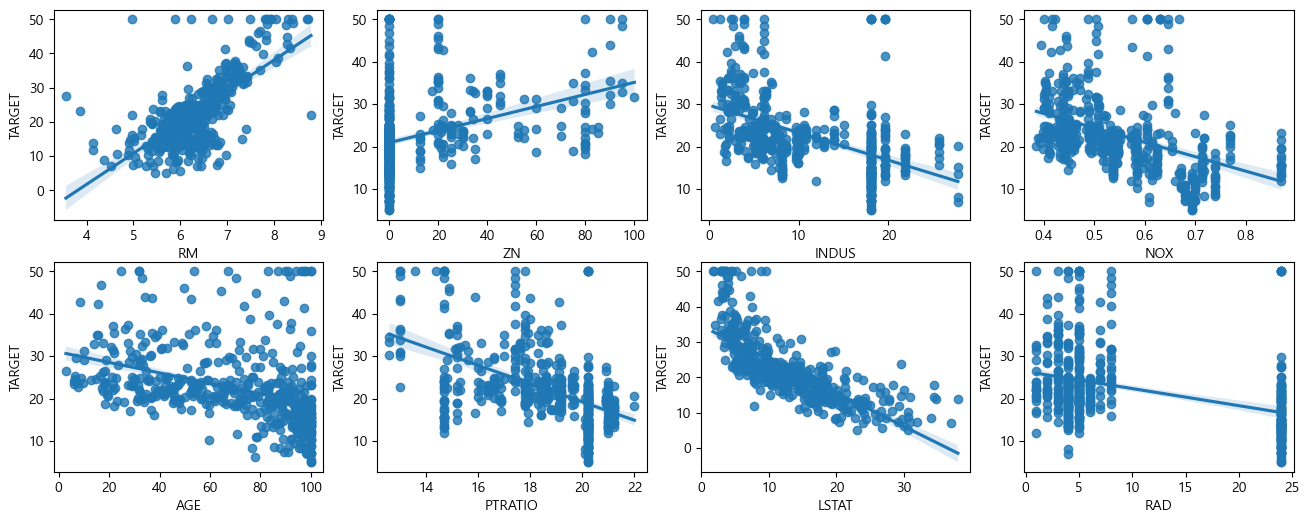

In [33]:
import seaborn as sns

# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
# plt.subplots(1,1)
# sns.scatterplot(boston_df.RM, boston_df.TARGET)
lm_features = ['RM', 'ZN', 'INDUS',  'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD' ]
fig, axs = plt.subplots(figsize=(16,6), ncols=4, nrows=2)

for i, feature in enumerate(lm_features):
    row, col = i // 4, i % 4
    sns.regplot(ax=axs[row][col], data=boston_df, x=feature, y='TARGET')

In [43]:
boston_df.RM.shape

(506,)

In [42]:
target.shape

(506,)

In [56]:
# X_train = data[:, 5]# 학습 데이터의 전체 행, 5번 열
X_train = boston_df.RM.values # RM 열
y_train = target # target 데이터

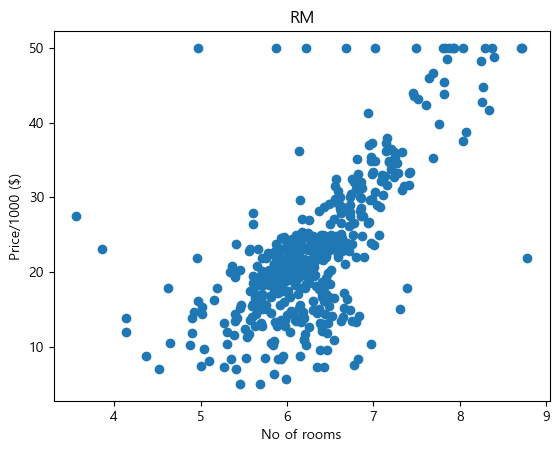

In [67]:
import matplotlib.pyplot as plt

# X_train, target 산점도 그리기
plt.plot(X_train, target, 'o')

plt.xlabel("No of rooms")
plt.ylabel("Price/1000 ($)")
plt.title('RM')
plt.show()

In [58]:
# Linear Regression OLS로 학습/예측/평가 수행. 
from sklearn.linear_model import LinearRegression

#LinearRegression
lg_clf = LinearRegression()

# 학습 진행
lg_clf.fit(X_train.reshape(-1,1), y_train)
# lg_clf.fit(X_train, y_train)

# 최종 목적은 회귀 선을 위한 가중치와 절편을 구하는 것
print('가중치(기울기):',lg_clf.coef_)
print('편향:',lg_clf.intercept_)

가중치(기울기): [9.10210898]
편향: -34.670620776438554


In [76]:
# X_train
y_pred = lg_clf.predict(X_train.reshape(-1,1))

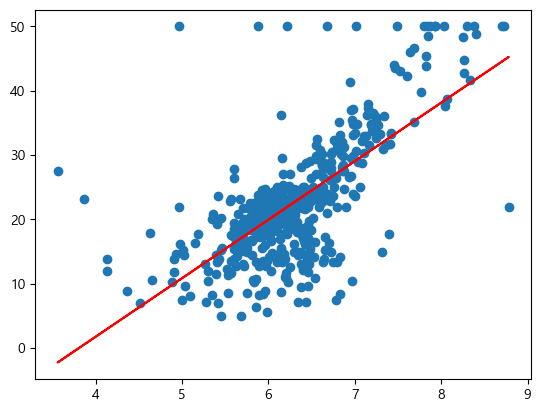

In [77]:
# 실제 학습 데이터와 회귀선
import numpy as np

# X_train, target 산점도를 그려 봅니다.
plt.plot(X_train, target, 'o')

# 회귀선 
# 우리 모델의 예측값
plt.plot(X_train, y_pred, 'red')
plt.show()

In [61]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('R2 score:', r2_score(y_train, y_pred))

print('MAE:', mean_absolute_error(y_train, y_pred))
print('MSE:', mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred)))

R2 score: 0.48352545599133423
MAE: 4.4477729015322325
MSE: 43.60055177116956
RMSE: 6.603071389222561


## 실습 LSTAT 지표
LSTAT으로 학습하고 평가지표를 산출

In [78]:
X_train1 = boston_df.LSTAT.values # RM 열

In [83]:
print(X_train1.shape)
print(X_train1.reshape(-1,1).shape)

(506,)
(506, 1)


In [79]:
lg_clf1 = LinearRegression()
lg_clf1.fit(X_train1.reshape(-1,1), y_train)
print('가중치(기울기):',lg_clf1.coef_)
print('편향:',lg_clf1.intercept_)

가중치(기울기): [-0.95004935]
편향: 34.5538408793831


In [80]:
y_pred1 = lg_clf1.predict(X_train1.reshape(-1,1))
print('R2 score:', r2_score(y_train, y_pred1))
print('MAE:', mean_absolute_error(y_train, y_pred1))
print('MSE:', mean_squared_error(y_train, y_pred1))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred1)))

R2 score: 0.5441462975864797
MAE: 4.505281166250568
MSE: 38.48296722989415
RMSE: 6.20346413142642


In [98]:
# AGE 지표
X_train2 = boston_df.AGE.values

lg_clf3 = LinearRegression()
lg_clf3.fit(X_train2.reshape(-1,1), y_train)

y_pred3 = lg_clf3.predict(X_train2.reshape(-1,1))
print('R2 score:', r2_score(y_train, y_pred3))
print('MAE:', mean_absolute_error(y_train, y_pred3))
print('MSE:', mean_squared_error(y_train, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred3)))

R2 score: 0.14209474407780442
MAE: 5.984744717749342
MSE: 72.42398092899337
RMSE: 8.510228018625199


In [102]:
from sklearn.model_selection import train_test_split

# data, target 을 7:3으로 훈련데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=.3, random_state=50)
X_train.shape, X_test.shape # 비율이 맞는지 개수로 확인

((354, 13), (152, 13))

In [105]:
# 학습 진행
# 학습 데이터와 학습 라벨
clf = LinearRegression()
clf.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [106]:
# 가중치와 절편
print('가중치(기울기):', clf.coef_) # 열별로 가지는 기울기값(w)
print('상수(절편):', clf.intercept_)

가중치(기울기): [-1.02245423e-01  3.11044112e-02  1.43693788e-02  1.65964577e+00
 -1.58693910e+01  5.03222436e+00 -7.16365483e-04 -1.31353766e+00
  2.55945159e-01 -1.23369178e-02 -9.03145563e-01  9.65756208e-03
 -4.22793524e-01]
상수(절편): 25.469528442762773


In [113]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 컬럼명에 유의
coefs = pd.Series(data=np.round(clf.coef_, 1), index=feature_names)
coefs.sort_values(ascending=False)

RM          5.0
CHAS        1.7
RAD         0.3
INDUS       0.0
ZN          0.0
B           0.0
TAX        -0.0
AGE        -0.0
CRIM       -0.1
LSTAT      -0.4
PTRATIO    -0.9
DIS        -1.3
NOX       -15.9
dtype: float64

In [115]:
# X_test 예측
pred_X_test = clf.predict(X_test)

In [117]:
print('R2 score:', r2_score(y_test, pred_X_test))
print('MAE:', mean_absolute_error(y_test, pred_X_test))
print('MSE:', mean_squared_error(y_test, pred_X_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, pred_X_test)))

R2 score: 0.6685538790447969
MAE: 3.678977534499437
MSE: 33.868033996670185
RMSE: 5.819624901715762


# 피처의 개수를 줄여서 테스트

In [146]:
X = boston_df.drop(['ZN','RAD', 'NOX', 'TARGET'], axis=1)
X.head()

,CRIM,INDUS,CHAS,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT
0,0.00632,2.31,0.0,6.575,65.2,4.0900,296.0,15.3,396.90,4.98
1,0.02731,7.07,0.0,6.421,78.9,4.9671,242.0,17.8,396.90,9.14
2,0.02729,7.07,0.0,7.185,61.1,4.9671,242.0,17.8,392.83,4.03
3,0.03237,2.18,0.0,6.998,45.8,6.0622,222.0,18.7,394.63,2.94
4,0.06905,2.18,0.0,7.147,54.2,6.0622,222.0,18.7,396.90,5.33


In [147]:
from sklearn.model_selection import train_test_split

# data, target 을 7:3으로 훈련데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(X.values, target, test_size=.3, random_state=50)
X_train.shape, X_test.shape

((354, 10), (152, 10))

In [148]:
clf = LinearRegression()
clf.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [149]:
coefs = pd.Series(data=np.round(clf.coef_, 1), index=X.columns)
coefs.sort_values(ascending=False)

RM         5.6
CHAS       1.7
B          0.0
TAX       -0.0
AGE       -0.0
CRIM      -0.1
INDUS     -0.1
LSTAT     -0.4
PTRATIO   -0.7
DIS       -0.9
dtype: float64

In [150]:
y_pred = clf.predict(X_test)

In [151]:
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score: 0.6327128990869971
MAE: 3.7714060688767845
MSE: 37.530359336868685
RMSE: 6.1262026849320526


# 모델 저장과 탑재

In [152]:
import joblib # 보통 pickle보다 대용량일 경우 사용. 또한 통.상.적으로 속도도 빠름
# joblib을 사용하여 모델 저장
model_filename = 'boston_lg_clf.joblib'
joblib.dump(clf, model_filename)

['boston_lg_clf.joblib']

In [154]:
!chcp 65001

Active code page: 65001


In [155]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
loaded_model = None
try: # 파일이 있으면 모델 로드
    loaded_model = joblib.load('boston_lg_clf.joblib')
except FileNotFoundError as e:
    print(e)

In [157]:
loaded_model.coef_

array([-6.41475845e-02, -1.27857282e-01,  1.71318601e+00,  5.58994868e+00,
       -2.00709190e-02, -9.19390557e-01, -1.84829825e-03, -7.06654733e-01,
        1.02058677e-02, -4.25491272e-01])

In [161]:
pred = loaded_model.predict(X_test)

In [163]:
pred.shape

(152,)

# 실습: 주택가격 모델

In [178]:
import ssl # 위 에러에 대한 대처법
data_url = "https://lib.stat.cmu.edu/datasets/boston"
ssl._create_default_https_context = ssl._create_unverified_context

raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD','TAX', 'PTRATIO', 'B', 'LSTAT']

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\USER\AppData\Local\Temp\ipykernel_12712\474443945.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [181]:
boston_df = pd.DataFrame(data, columns=feature_names)  # 학습 데이터
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [182]:
# data, target 을 7:3으로 훈련데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(boston_df.values, target, test_size=.3, random_state=50)
X_train.shape, X_test.shape

((354, 13), (152, 13))

In [183]:
clf = LinearRegression()
clf.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [187]:
y_pred = clf.predict(X_test)
y_pred[0]

np.float64(9.705361625519195)

In [188]:
# 1개의 학습 데이터
idx = 100
print( data[idx] )
print( target[idx] )

[1.4866e-01 0.0000e+00 8.5600e+00 0.0000e+00 5.2000e-01 6.7270e+00
 7.9900e+01 2.7778e+00 5.0000e+00 3.8400e+02 2.0900e+01 3.9476e+02
 9.4200e+00]
27.5


In [191]:
# 모델이 예측한 1개 학습 데이터 예측치
print("예측:", clf.predict( data[idx].reshape(1,-1)) )
print(target[idx])

예측: [24.96734923]
27.5


In [192]:
import joblib # 보통 pickle보다 대용량일 경우 사용. 또한 통.상.적으로 속도도 빠름
# joblib을 사용하여 모델 저장
model_filename = 'boston_lg_clf.joblib'
joblib.dump(clf, model_filename)

['boston_lg_clf.joblib']

In [193]:
loaded_model = None
try: # 파일이 있으면 모델 로드
    loaded_model = joblib.load('boston_lg_clf.joblib')
except FileNotFoundError as e:
    print(e)

# decision tree

In [ ]:
import numpy as np
import pandas as pd

# 풍속을 threshold 값에 따라 분리하는 의사결정나무 모델 함수
def binary_tree(data, threshold):
    yes, no = [], []
    
    # data로부터 풍속 값마다 비교를 하기 위한 반복문
    for wind in data['풍속']:
    
        # threshold 값과 비교하여 분리합니다.
        if wind > threshold:
            yes.append(wind)
        else:
            no.append(wind)
    
    # 예측한 결과를 DataFrame 형태로 저장합니다.
    data_yes = pd.DataFrame({'풍속': yes, '예상 지연 여부': ['Yes']*len(yes)})  # yes의 길이만큼 지연 여부에 'Yes'를 넣어줌
    data_no = pd.DataFrame({'풍속': no, '예상 지연 여부': ['No']*len(no)})      # no의 길이만큼 지연 여 부에 'No'를 넣어줌
    
    return pd.concat([data_no, data_yes])


In [197]:
# 풍속에 따른 항공 지연 여부 데이터
Wind = [1, 1.5, 2.5, 5, 5.5, 6.5]
Delay  = ['No', 'No', 'No', 'Yes', 'Yes', 'Yes']

# 위 데이터를 DataFrame 형태로 저장합니다.
data = pd.DataFrame({'풍속': Wind, '지연 여부': Delay})
print(data,'\n')

    풍속 지연 여부
0  1.0    No
1  1.5    No
2  2.5    No
3  5.0   Yes
4  5.5   Yes
5  6.5   Yes 



In [ ]:
# binary_tree 모델을 사용하여 항공 지연 여부를 예측합니다.
# (threshold에 값을 넣어서 결과를 확인)
# 지연 여부 == 예상 지연 여부가 되도록 data_pred에 할당
pred = binary_tree(data, threshold=2)
print(pred)

    풍속 예상 지연 여부
0  1.0       No
1  1.5       No
0  2.5      Yes
1  5.0      Yes
2  5.5      Yes
3  6.5      Yes


In [32]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

In [24]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

# sklearn에 저장된 데이터를 불러옵니다.
X, Y = load_iris(return_X_y = True)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.3, random_state=50)
X_train.shape, y_train.shape

((105, 4), (105,))

In [26]:
y_train

array([0, 0, 0, 2, 2, 1, 0, 0, 1, 2, 1, 1, 0, 0, 2, 2, 1, 2, 0, 0, 2, 1,
       0, 1, 0, 2, 2, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 2, 2,
       2, 1, 2, 0, 2, 0, 1, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 0, 1,
       2, 0, 2, 1, 1, 1, 1, 2, 1, 0, 2, 0, 2, 0, 1, 2, 0, 0, 1, 2, 1, 0,
       0, 0, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 1, 2, 0, 2, 2])

In [27]:
X_train[4]

array([5.8, 2.8, 5.1, 2.4])

In [28]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
pred = clf.predict(X_test)
accuracy_score(pred, y_test)

0.9555555555555556

In [ ]:
# # 전체 코드
# from sklearn.datasets import load_iris
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# # sklearn에 저장된 데이터를 불러옵니다.
# X, Y = load_iris(return_X_y = True)
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.3, random_state=50)
# clf = DecisionTreeClassifier()
# clf.fit(X_train, y_train)
# pred = clf.predict(X_test)
# accuracy_score(pred, y_test)

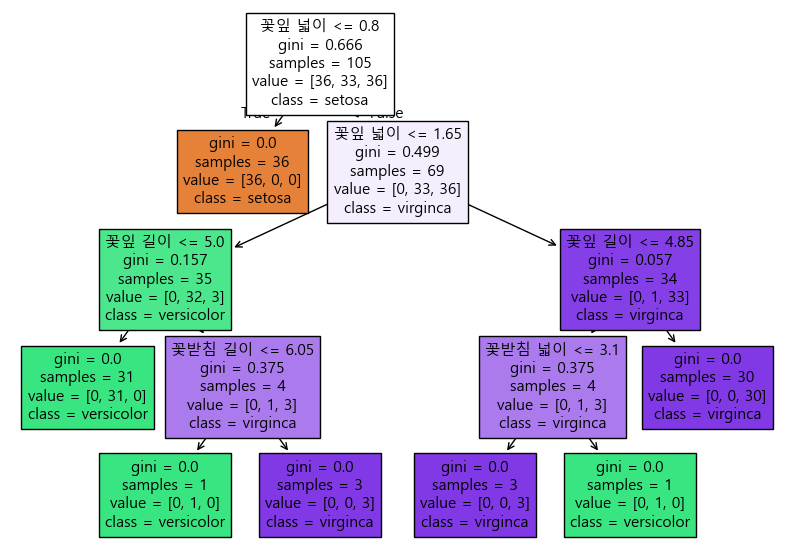

In [34]:
# 학습한 결과를 출력합니다
fig = plt.figure(figsize=(10,7))
tree.plot_tree(clf,
               feature_names=['꽃받침 길이','꽃받침 넓이','꽃잎 길이','꽃잎 넓이'],
               class_names=['setosa','versicolor','virginca'], 
               filled=True
)

plt.show()

In [36]:
# test_X에 대해서 예측합니다.
pred_X = clf.predict(X_test)
print('test_X에 대한 예측값 : \n{}'.format(pred_X))

test_X에 대한 예측값 : 
[1 1 0 0 2 2 2 0 0 1 0 2 0 2 1 0 1 0 1 2 2 1 0 2 1 2 1 1 1 2 2 1 1 2 0 0 1
 1 1 0 0 1 2 0 2]


In [37]:
y_test

array([1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 1, 2, 1,
       0, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 0, 0, 1, 2, 1, 0, 0, 1, 2, 0,
       2])

In [38]:
accuracy_score(pred_X, y_test)

0.9555555555555556

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels


# sklearn에 저장된 데이터를 불러 옵니다.
X,y = load_breast_cancer(return_X_y=True)

# 데이터 정보를 출력합니다
print('전체 샘플 개수: ',len(X))
print('X의 feature 개수: ',len(X[0]))

type(X)

전체 샘플 개수:  569
X의 feature 개수:  30


numpy.ndarray

In [70]:
df = pd.DataFrame(X)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [80]:
# 학습용 평가용 데이터로 분리합니다
train_X, test_X, train_Y, test_Y = train_test_split(X,y, random_state=42, test_size=.2)


# 분리된 평가용 데이터 정보를 출력합니다
print('평가용 샘플 개수: ',len(test_Y))
print('클래스 0인 평가용 샘플 개수: ', len(test_Y)-sum(test_Y))
print('클래스 1인 평가용 샘플 개수: ', sum(test_Y),'\n')  # 샘플당 값이 1이므로 sum = 개수


평가용 샘플 개수:  114
클래스 0인 평가용 샘플 개수:  43
클래스 1인 평가용 샘플 개수:  71 



In [84]:
# DTmodel에 의사결정나무 모델을 초기화하고 학습합니다
dt_cls = DecisionTreeClassifier()
dt_cls.fit(train_X, train_Y)

# test_X을 바탕으로 예측한 값을 저장합니다
y_pred = dt_cls.predict(test_X)

In [85]:
# 혼동 행렬을 계산합니다
cm = confusion_matrix(test_Y, y_pred)
print('Confusion Matrix : \n {}'.format(cm))

Confusion Matrix : 
 [[39  4]
 [ 4 67]]


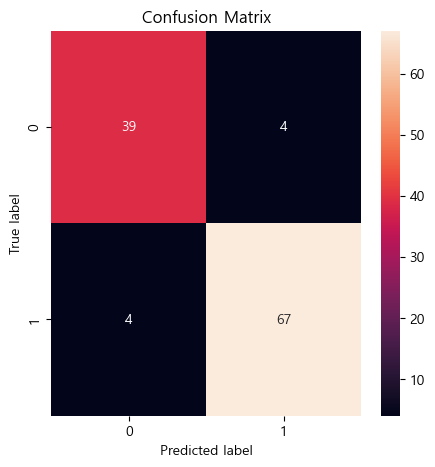

In [87]:
# 혼동 행렬의 heatmap 출력합니다
fig = plt.figure(figsize=(5,5))

ax = sns.heatmap(cm, annot=True)

ax.set(title='Confusion Matrix',
            ylabel='True label',
            xlabel='Predicted label')
# fig.savefig("decistion_tree.png")
plt.show()

In [90]:
# train_X, test_X 각각 예측한 값을 저장합니다
pred1 = dt_cls.predict(train_X)
pred2 = dt_cls.predict(test_X)

# 혼동 행렬을 계산합니다
cm1 = confusion_matrix(train_Y, pred1)
cm2 = confusion_matrix(test_Y, pred2)

print('train_X Confusion Matrix : \n {}'.format(cm1))
print('test_X Confusion Matrix : \n {}'.format(cm2))
# print('train_X Confusion Matrix : \n {}'.format(cm_train))
# print('test_X Confusion Matrix : \n {}'.format(cm_test))


train_X Confusion Matrix : 
 [[169   0]
 [  0 286]]
test_X Confusion Matrix : 
 [[39  4]
 [ 4 67]]


In [ ]:
# train_X, train_Y 정확도를 계산합니다.
print(dt_cls.score(train_X, train_Y))
# accuracy_score(train_Y, pred1)  # 위와 동일

# test_X, test_Y 정확도를 계산합니다.
print(dt_cls.score(test_X, test_Y))
# accuracy_score(test_Y, pred2)     # 위와 동일

# 정확도를 출력합니다.
# print('train_X Accuracy: %f' % (acc_train))  # train_X Accuracy: 1.000000
# print('test_X Accuracy: %f' % (acc_test))    # test_X Accuracy: 0.947368

1.0
0.9298245614035088


0.9298245614035088

In [95]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

#1. 정밀도를 계산합니다.
precision_train = precision_score(train_Y, pred1)
precision_test = precision_score(test_Y, pred2)

# 정밀도를 출력합니다.
print('train_X Precision: %f' % (precision_train))     # train_X Precision: 1.000000
print('test_X Precision: %f' % (precision_test),'\n')  # test_X Precision: 0.944444 

#2. 재현율을 계산합니다.
recall_train = recall_score(train_Y, pred1)
recall_test = recall_score(test_Y, pred2)

# 재현율을 출력합니다.
print('train_X Recall: %f' % (recall_train))  # train_X Recall: 1.000000
print('test_X Recall: %f' % (recall_test))    # test_X Recall: 0.957746


train_X Precision: 1.000000
test_X Precision: 0.943662 

train_X Recall: 1.000000
test_X Recall: 0.943662


In [98]:
from sklearn.metrics import classification_report

print(classification_report(test_Y, pred2))
print(classification_report(train_Y, pred1))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        43
           1       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       286

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

